<a href="https://colab.research.google.com/github/ojaspaul123/DL-journey/blob/main/ANN/Weight_Initialization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('ushape.csv')
df.head()

Saving ushape.csv to ushape (1).csv


,X,Y,class
0,-0.0711,0.4749,1.0
1,0.6898,-0.3752,1.0
2,0.8086,0.5634,0.0
3,0.2620,0.2319,1.0
4,0.0864,0.9218,0.0


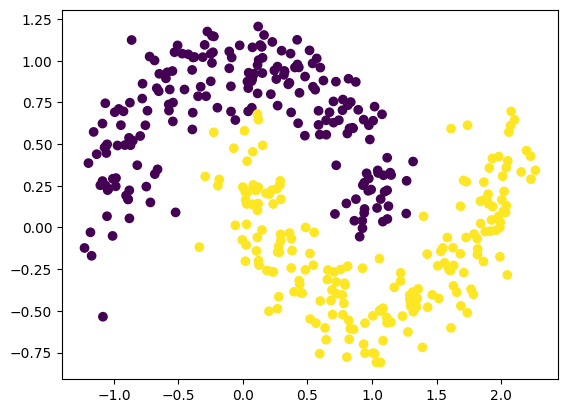

In [4]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [5]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [6]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [7]:
model = Sequential()

model.add(Dense(2,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Set parameters to 0
model.get_weights()

[array([[ 1.0227166 ,  0.06408453],
        [-1.1446915 , -0.8026538 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.6438912 ],
        [0.43188453]], dtype=float32),
 array([0.], dtype=float32)]

In [9]:
initial_weights = model.get_weights()

In [36]:
initial_weights[0] = np.zeros(model.get_weights()[0].shape)*0.5
initial_weights[1] = np.zeros(model.get_weights()[1].shape)*0.5
initial_weights[2] = np.zeros(model.get_weights()[2].shape)*0.5
initial_weights[3] = np.zeros(model.get_weights()[3].shape)*0.5

In [37]:
model.set_weights(initial_weights)

In [38]:
model.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [39]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [40]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.4844 - loss: 0.6932 - val_accuracy: 0.5375 - val_loss: 0.6930
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4906 - loss: 0.6932 - val_accuracy: 0.5375 - val_loss: 0.6931
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4906 - loss: 0.6932 - val_accuracy: 0.4625 - val_loss: 0.6932
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5094 - loss: 0.6932 - val_accuracy: 0.4625 - val_loss: 0.6932
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5094 - loss: 0.6931 - val_accuracy: 0.4625 - val_loss: 0.6933
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5094 - loss: 0.6931 - val_accuracy: 0.4625 - val_loss: 0.6934
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5094 - loss: 0.6931 - val_accuracy: 0.4625 - val_loss: 0.6934
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5094 - loss: 0.6931 - val_accuracy: 0.4625 

In [41]:
model.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([-0.03491313], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


<Axes: >

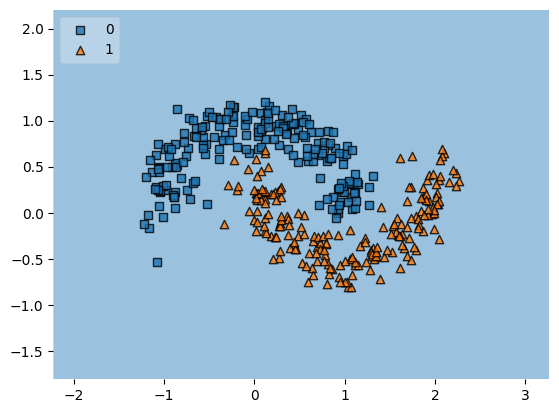

In [42]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

**ReLU ones**

In [26]:
model_1= Sequential()

model_1.add(Dense(2,activation='relu',input_dim=2))
model_1.add(Dense(1,activation='sigmoid'))

model_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Set parameters to 0
model_1.get_weights()

[array([[1.0751466 , 0.5572405 ],
        [0.85990036, 0.5928787 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.11869872],
        [1.1154343 ]], dtype=float32),
 array([0.], dtype=float32)]

In [28]:
initial_weights = model_1.get_weights()

In [29]:
initial_weights[0] = np.ones(model_1.get_weights()[0].shape)*0.5
initial_weights[1] = np.ones(model_1.get_weights()[1].shape)*0.5
initial_weights[2] = np.ones(model_1.get_weights()[2].shape)*0.5
initial_weights[3] = np.ones(model_1.get_weights()[3].shape)*0.5

In [30]:
model_1.set_weights(initial_weights)

In [31]:
model_1.get_weights()

[array([[0.5, 0.5],
        [0.5, 0.5]], dtype=float32),
 array([0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [32]:
model_1.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [33]:
history = model_1.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.4906 - loss: 0.9119 - val_accuracy: 0.5375 - val_loss: 0.8283
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4906 - loss: 0.8983 - val_accuracy: 0.5375 - val_loss: 0.8175
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4906 - loss: 0.8856 - val_accuracy: 0.5375 - val_loss: 0.8070
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4906 - loss: 0.8741 - val_accuracy: 0.5375 - val_loss: 0.7968
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4906 - loss: 0.8617 - val_accuracy: 0.5375 - val_loss: 0.7877
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4906 - loss: 0.8507 - val_accuracy: 0.5375 - val_loss: 0.7790
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4906 - loss: 0.8408 - val_accuracy: 0.5375 - val_loss: 0.7705
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4906 - loss: 0.8311 - val_accuracy: 0.5375 

In [34]:
model_1.get_weights()

[array([[ 0.94557834,  0.94557834],
        [-0.17818567, -0.17818567]], dtype=float32),
 array([0.21314047, 0.21314047], dtype=float32),
 array([[0.37877473],
        [0.37877473]], dtype=float32),
 array([-0.17492467], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


<Axes: >

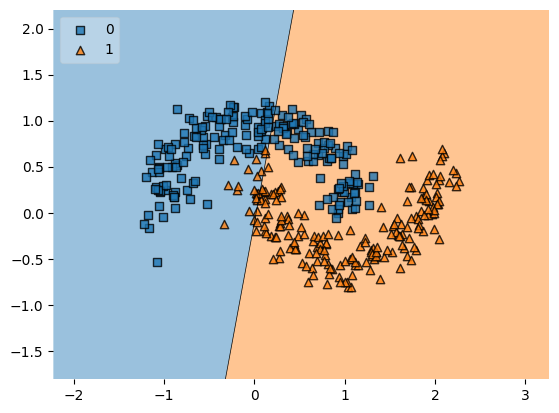

In [35]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model_1, legend=2)

**Tanh ones**

In [43]:
model_2= Sequential()

model_2.add(Dense(2,activation='tanh',input_dim=2))
model_2.add(Dense(1,activation='sigmoid'))

model_2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [44]:
# Set parameters to 0
model_2.get_weights()

[array([[-0.5856455 , -0.44323266],
        [-0.4568531 ,  0.03779912]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.6698028 ],
        [0.96604383]], dtype=float32),
 array([0.], dtype=float32)]

In [45]:
initial_weights = model_2.get_weights()

In [46]:
initial_weights[0] = np.ones(model_2.get_weights()[0].shape)*0.5
initial_weights[1] = np.ones(model_2.get_weights()[1].shape)*0.5
initial_weights[2] = np.ones(model_2.get_weights()[2].shape)*0.5
initial_weights[3] = np.ones(model_2.get_weights()[3].shape)*0.5

In [47]:
model_2.set_weights(initial_weights)

In [48]:
model_2.get_weights()

[array([[0.5, 0.5],
        [0.5, 0.5]], dtype=float32),
 array([0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [49]:
model_2.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [50]:
history = model_2.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4906 - loss: 0.8487 - val_accuracy: 0.5375 - val_loss: 0.7827
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4906 - loss: 0.8398 - val_accuracy: 0.5375 - val_loss: 0.7754
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4906 - loss: 0.8307 - val_accuracy: 0.5375 - val_loss: 0.7684
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4906 - loss: 0.8227 - val_accuracy: 0.5375 - val_loss: 0.7613
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4906 - loss: 0.8144 - val_accuracy: 0.5375 - val_loss: 0.7547
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4906 - loss: 0.8069 - val_accuracy: 0.5375 - val_loss: 0.7482
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4906 - loss: 0.7989 - val_accuracy: 0.5375 - val_loss: 0.7423
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4906 - loss: 0.7921 - val_accuracy: 0.53

In [51]:
model_2.get_weights()

[array([[ 0.80758226,  0.80758226],
        [-0.48383114, -0.48383114]], dtype=float32),
 array([-0.19260643, -0.19260643], dtype=float32),
 array([[0.76153123],
        [0.76153123]], dtype=float32),
 array([-0.06268214], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


<Axes: >

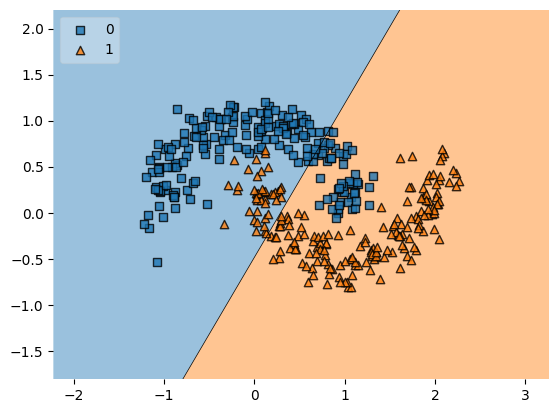

In [52]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model_2, legend=2)

**Sigmond ones**

In [63]:
model_3= Sequential()

model_3.add(Dense(10,activation='sigmoid',input_dim=2))
model_3.add(Dense(1,activation='sigmoid'))

model_3.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [64]:
# Set parameters to 0
model_3.get_weights()

[array([[ 0.07240134, -0.63687074, -0.18391752, -0.16498584,  0.12296462,
         -0.1177544 , -0.5132867 ,  0.6544121 , -0.34278774, -0.38769367],
        [ 0.33356267,  0.23876274,  0.04094416,  0.2416678 , -0.11768109,
          0.60220665, -0.03732306, -0.54099864, -0.27134594, -0.19127572]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.6773589 ],
        [ 0.32853395],
        [ 0.02892333],
        [-0.37440115],
        [ 0.45052344],
        [-0.7250549 ],
        [-0.22369629],
        [-0.38639545],
        [-0.04770231],
        [ 0.6536135 ]], dtype=float32),
 array([0.], dtype=float32)]

In [65]:
initial_weights = model_3.get_weights()

In [66]:
initial_weights[0] = np.ones(model_3.get_weights()[0].shape)*0.5
initial_weights[1] = np.ones(model_3.get_weights()[1].shape)*0.5
initial_weights[2] = np.ones(model_3.get_weights()[2].shape)*0.5
initial_weights[3] = np.ones(model_3.get_weights()[3].shape)*0.5

In [67]:
model_3.set_weights(initial_weights)

In [68]:
model_3.get_weights()

[array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]], dtype=float32),
 array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [69]:
model_3.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [70]:
history = model_3.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4906 - loss: 2.0143 - val_accuracy: 0.5375 - val_loss: 1.7945
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4906 - loss: 1.9671 - val_accuracy: 0.5375 - val_loss: 1.7542
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4906 - loss: 1.9230 - val_accuracy: 0.5375 - val_loss: 1.7134
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4906 - loss: 1.8787 - val_accuracy: 0.5375 - val_loss: 1.6732
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4906 - loss: 1.8335 - val_accuracy: 0.5375 - val_loss: 1.6342
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4906 - loss: 1.7898 - val_accuracy: 0.5375 - val_loss: 1.5959
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4906 - loss: 1.7466 - val_accuracy: 0.5375 - val_loss: 1.5584
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4906 - loss: 1.7059 - val_accuracy: 0.

In [71]:
model_3.get_weights()

[array([[0.87158895, 0.87158895, 0.87158895, 0.87158895, 0.87158895,
         0.87158895, 0.87158895, 0.87158895, 0.87158895, 0.87158895],
        [0.05770668, 0.05770668, 0.05770668, 0.05770668, 0.05770668,
         0.05770668, 0.05770668, 0.05770668, 0.05770668, 0.05770668]],
       dtype=float32),
 array([0.14372413, 0.14372413, 0.14372413, 0.14372413, 0.14372413,
        0.14372413, 0.14372413, 0.14372413, 0.14372413, 0.14372413],
       dtype=float32),
 array([[0.0416912],
        [0.0416912],
        [0.0416912],
        [0.0416912],
        [0.0416912],
        [0.0416912],
        [0.0416912],
        [0.0416912],
        [0.0416912],
        [0.0416912]], dtype=float32),
 array([-0.07084474], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


<Axes: >

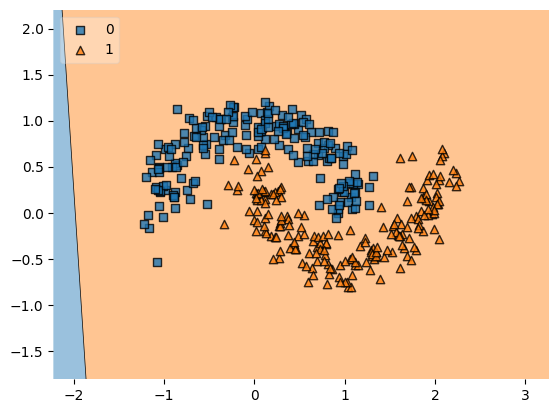

In [72]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model_3, legend=2)